In [1]:
import pandas as pd
#Loading and reading the dataset
file_path = 'amazon.csv'
df = pd.read_csv(file_path)
#Showing a few rows of data
df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [2]:
# Displaying a summary of the dataset to understand types and missing values
print(df.info())

# Basic statistics for numerical columns to get a sense of the data distribution
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   object
dtypes: obj

## Text Preprocessing and Sentiment Analysis

Customer review text was cleaned before analysis by:
- converting text to lowercase
- removing punctuation
- removing numerical values

TextBlob was then used to calculate sentiment polarity scores for each review. Polarity values range from -1 (negative sentiment) to +1 (positive sentiment).


In [3]:
from textblob import TextBlob
import re

#Function that cleans the text and converts to lowercase, removes punctuation as well as numbers and extra spaces
def clean_text(text):
    """
    Clean review text before sentiment analysis.
    """
    if not isinstance(text, str):
        return ""

    text = text.lower()                      
    text = re.sub(r"[^\w\s]", "", text)      
    text = re.sub(r"\d+", "", text)           
    text = re.sub(r"\s+", " ", text).strip() 
    return text


#Apply cleaning function to review_content
df["clean_review_content"] = df["review_content"].apply(clean_text)


#Function to calculate TextBlob sentiment polarity
def analyze_sentiment(text):
    """
    Return TextBlob sentiment polarity.
    Score ranges from -1 negative to +1 positive.
    """
    return TextBlob(text).sentiment.polarity


#Apply sentiment analysis
df["sentiment_score"] = df["clean_review_content"].apply(analyze_sentiment)


#Display the first few rows
df[["review_content", "clean_review_content", "sentiment_score"]].head()

,review_content,clean_review_content,sentiment_score
0,Looks durable Charging is fine tooNo complains...,looks durable charging is fine toono complains...,0.481944
1,I ordered this cable to connect my phone to An...,i ordered this cable to connect my phone to an...,0.274318
2,"Not quite durable and sturdy,https://m.media-a...",not quite durable and sturdyhttpsmmediaamazonc...,0.600000
3,"Good product,long wire,Charges good,Nice,I bou...",good productlong wirecharges goodnicei bought ...,0.240370
4,"Bought this instead of original apple, does th...",bought this instead of original apple does the...,0.262740


## Descriptive Statistics for Sentiment Scores

Summary statistics were calculated to understand the distribution of customer sentiment scores generated using TextBlob.

In [4]:
#Generate statistics for sentiment scores
sentiment_statistics = df["sentiment_score"].describe()

print("Descriptive Statistics for Sentiment Scores")
print("-" * 50)
print(sentiment_statistics)

Descriptive Statistics for Sentiment Scores
--------------------------------------------------
count    1465.000000
mean        0.270115
std         0.137632
min        -0.600000
25%         0.177652
50%         0.257500
75%         0.351429
max         1.000000
Name: sentiment_score, dtype: float64


## Correlation Between Ratings and Sentiment Scores

Customer ratings were converted into numerical values to investigate the relationship between review ratings and TextBlob sentiment polarity scores.

Correlation analysis helps determine whether more positive review text is associated with higher customer ratings.

In [5]:
#Converting ratings to numeric values
df["numeric_rating"] = pd.to_numeric(
    df["rating"],
    errors="coerce")

#Calculating the correlation between ratings and sentiment scores
correlation = df[["numeric_rating", "sentiment_score"]].corr()

print("Correlation Matrix")
print(correlation)

Correlation Matrix
                 numeric_rating  sentiment_score
numeric_rating         1.000000         0.182465
sentiment_score        0.182465         1.000000


## Visualisation of Sentiment Patterns

Visualisations were created to help in understanding the distribution of sentiment polarity scores and the relationship between customer ratings and text sentiments.

The histogram shows how sentiment scores are distributed across the dataset, while the scatter plot explores whether higher customer ratings are generally associated with more positive review sentiment.

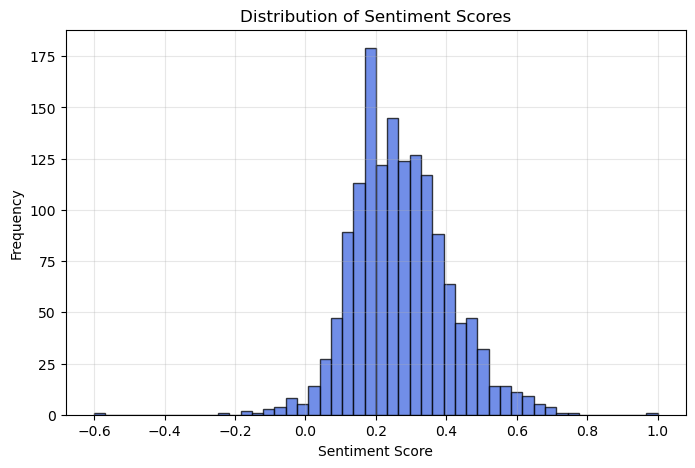

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

#Histogram of sentiment scores
plt.figure(figsize=(8, 5))

plt.hist(
    df["sentiment_score"],
    bins=50,
    alpha=0.75,
    color="royalblue",
    edgecolor="black")

plt.title("Distribution of Sentiment Scores")
plt.xlabel("Sentiment Score")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()

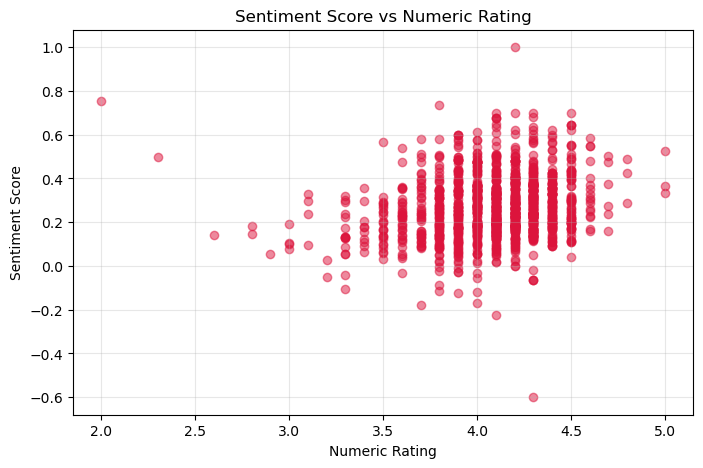

In [7]:
#Scatter plot: ratings vs sentiment
plt.figure(figsize=(8, 5))

plt.scatter(
    df["numeric_rating"],
    df["sentiment_score"],
    alpha=0.5,
    color="crimson")

plt.title("Sentiment Score vs Numeric Rating")
plt.xlabel("Numeric Rating")
plt.ylabel("Sentiment Score")

plt.grid(alpha=0.3)
plt.show()

The correlation analysis showed a weak positive relationship between customer ratings and sentiment scores. This suggests that reviews with higher ratings had more positive language, although the relationship was not strongly linear due to outliers within the data.

## Can TextBlob sentiment labels match the customer star ratings?

## Sentiment Classification Evaluation

To evaluate how well TextBlob sentiment scores align with customer ratings, star ratings were converted into sentiment labels: negative, neutral, and positive. TextBlob polarity scores were also converted into the same labels using threshold values.

This allows the sentiment analysis output to be compared against rating-based sentiment using accuracy, precision, recall, F1-score, and a confusion matrix.

In [8]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

#Convert star ratings into sentiment labels
def rating_to_sentiment(rating):
    if rating <= 2:
        return "negative"
    elif rating == 3:
        return "neutral"
    else:
        return "positive"

df["rating_sentiment"] = df["numeric_rating"].apply(rating_to_sentiment)


#Converting TextBlob polarity scores into sentiment labels
def textblob_to_sentiment(score):
    if score < -0.05:
        return "negative"
    elif score <= 0.05:
        return "neutral"
    else:
        return "positive"

df["textblob_sentiment"] = df["sentiment_score"].apply(textblob_to_sentiment)


#Evaluate TextBlob sentiment against rating-based sentiment
accuracy = accuracy_score(df["rating_sentiment"], df["textblob_sentiment"])

print("TextBlob Sentiment Classification Accuracy:")
print(round(accuracy, 4))

print("\nClassification Report:")
print(classification_report(df["rating_sentiment"], df["textblob_sentiment"]))

TextBlob Sentiment Classification Accuracy:
0.9666

Classification Report:
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00         1
     neutral       0.00      0.00      0.00         4
    positive       1.00      0.97      0.98      1460

    accuracy                           0.97      1465
   macro avg       0.33      0.32      0.33      1465
weighted avg       0.99      0.97      0.98      1465



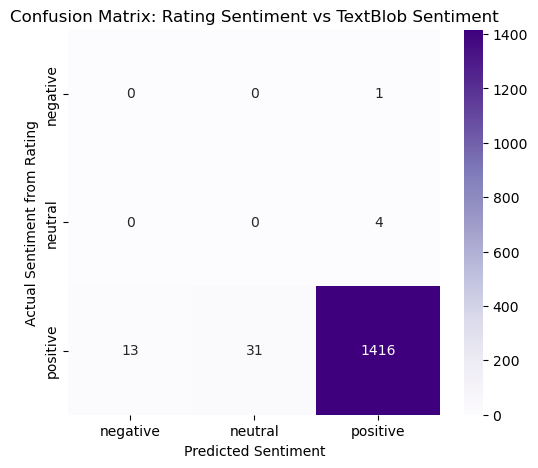

In [19]:
#Confusion matrix
labels = ["negative", "neutral", "positive"]

cm = confusion_matrix(
    df["rating_sentiment"],
    df["textblob_sentiment"],
    labels=labels)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels,
    cmap="Purples")

plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment from Rating")
plt.title("Confusion Matrix: Rating Sentiment vs TextBlob Sentiment")
plt.savefig("images/amazon_textblob_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()


The model achieves very high accuracy because the dataset is overall positive: 1460 out of 1465 reviews are positive based on the rating labels. However, it fails to correctly identify the small number of negative and neutral reviews.

Although the overall accuracy was high at 96.66%, this result is influenced by the strong class imbalance in the dataset. Most reviews were labelled as positive based on customer ratings, so TextBlob performed well on the positive class but failed to identify the small number of negative and neutral examples. This shows why accuracy alone can be misleading in imbalanced classification problems.

## VADER Sentiment Analysis

VADER was added as a second sentiment analysis method to compare against TextBlob. VADER is often useful for review-style text because it produces a compound sentiment score between -1 and +1, where negative values indicate negative sentiment and positive values indicate positive sentiment.

In [10]:
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

#Download VADER lexicon
nltk.download("vader_lexicon")

#Initialise VADER
sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Amaan\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [11]:
#Function to calculate VADER compound score
def get_vader_score(text):
    if not isinstance(text, str):
        return 0
    return sia.polarity_scores(text)["compound"]


#Applying VADER to the cleaned review text
df["vader_sentiment_score"] = df["clean_review_content"].apply(get_vader_score)

#Displaying the comparison with TextBlob
df[["clean_review_content", "sentiment_score", "vader_sentiment_score"]].head()

,clean_review_content,sentiment_score,vader_sentiment_score
0,looks durable charging is fine toono complains...,0.481944,0.9033
1,i ordered this cable to connect my phone to an...,0.274318,0.9816
2,not quite durable and sturdyhttpsmmediaamazonc...,0.600000,0.6808
3,good productlong wirecharges goodnicei bought ...,0.240370,0.8316
4,bought this instead of original apple does the...,0.262740,0.9831


In [12]:
print("Descriptive Statistics for VADER Sentiment Scores")
print("-" * 50)
print(df["vader_sentiment_score"].describe())

Descriptive Statistics for VADER Sentiment Scores
--------------------------------------------------
count    1465.000000
mean        0.821895
std         0.371565
min        -0.980800
25%         0.872200
50%         0.962500
75%         0.988700
max         0.999900
Name: vader_sentiment_score, dtype: float64


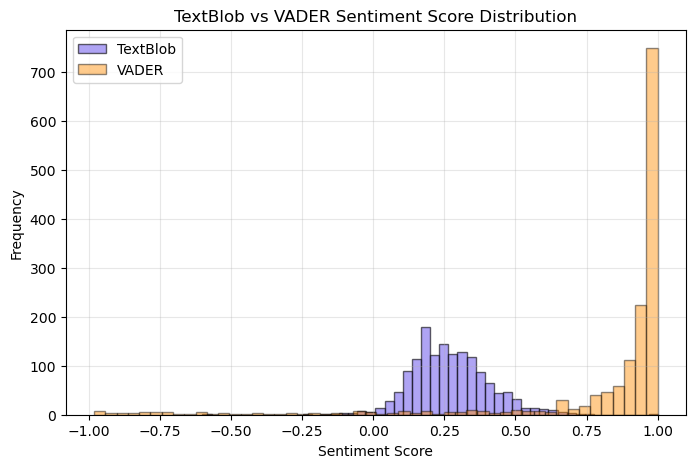

In [13]:
#TextBlob vs VADER distribution comparison
plt.figure(figsize=(8, 5))

#TextBlob histogram
plt.hist(
    df["sentiment_score"],
    bins=50,
    alpha=0.6,
    label="TextBlob",
    color="mediumslateblue",
    edgecolor="black")

#VADER histogram
plt.hist(
    df["vader_sentiment_score"],
    bins=50,
    alpha=0.45,
    label="VADER",
    color="darkorange",
    edgecolor="black")

plt.title("TextBlob vs VADER Sentiment Score Distribution")
plt.xlabel("Sentiment Score")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("images/amazon_textblob_vs_vader_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [14]:
textblob_corr = df["numeric_rating"].corr(df["sentiment_score"])
vader_corr = df["numeric_rating"].corr(df["vader_sentiment_score"])

print("Correlation with Numeric Rating")
print("-" * 50)
print(f"TextBlob correlation: {textblob_corr:.4f}")
print(f"VADER correlation:    {vader_corr:.4f}")

Correlation with Numeric Rating
--------------------------------------------------
TextBlob correlation: 0.1825
VADER correlation:    0.2288


In [15]:
def vader_to_sentiment(score):
    if score < -0.05:
        return "negative"
    elif score <= 0.05:
        return "neutral"
    else:
        return "positive"


df["vader_sentiment"] = df["vader_sentiment_score"].apply(vader_to_sentiment)

df[["numeric_rating", "rating_sentiment", "sentiment_score", "textblob_sentiment", "vader_sentiment_score", "vader_sentiment"]].head()

,numeric_rating,rating_sentiment,sentiment_score,textblob_sentiment,vader_sentiment_score,vader_sentiment
0,4.2,positive,0.481944,positive,0.9033,positive
1,4.0,positive,0.274318,positive,0.9816,positive
2,3.9,positive,0.600000,positive,0.6808,positive
3,4.2,positive,0.240370,positive,0.8316,positive
4,4.2,positive,0.262740,positive,0.9831,positive


In [16]:
print("VADER Sentiment Classification Accuracy:")
vader_accuracy = accuracy_score(df["rating_sentiment"], df["vader_sentiment"])
print(round(vader_accuracy, 4))

print("\nVADER Classification Report:")
print(classification_report(df["rating_sentiment"], df["vader_sentiment"]))

VADER Sentiment Classification Accuracy:
0.9406

VADER Classification Report:
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00         1
     neutral       0.00      0.00      0.00         4
    positive       1.00      0.94      0.97      1460

    accuracy                           0.94      1465
   macro avg       0.33      0.31      0.32      1465
weighted avg       0.99      0.94      0.97      1465



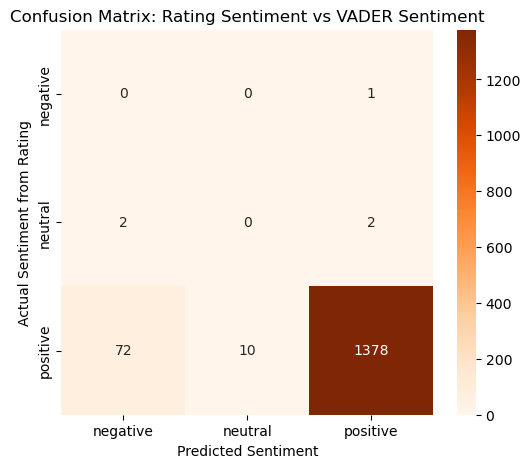

In [17]:
#VADER confusion matrix
labels = ["negative", "neutral", "positive"]

vader_cm = confusion_matrix(
    df["rating_sentiment"],
    df["vader_sentiment"],
    labels=labels)

plt.figure(figsize=(6, 5))

sns.heatmap(
    vader_cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels,
    cmap="Oranges")

plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment from Rating")
plt.title("Confusion Matrix: Rating Sentiment vs VADER Sentiment")
plt.show()

## VADER Results Interpretation

VADER was used as an additional sentiment analysis method to compare with TextBlob. Both methods produce sentiment scores between -1 and +1, but they may behave differently because VADER is designed for short, informal and review-style text.

The VADER results can be compared against TextBlob using:
- sentiment score distributions
- correlation with numeric ratings
- classification accuracy
- precision, recall and F1-score
- confusion matrices

This comparison helps assess whether VADER aligns more closely with customer star ratings than TextBlob.

## TextBlob vs VADER Comparison

TextBlob achieved a higher classification accuracy of 96.66%, compared with VADER's 94.06%. However, VADER showed a slightly stronger correlation with numeric ratings, with a correlation of 0.2288  compared with TextBlob's 0.1825.

This suggests that TextBlob performed better when sentiment scores were converted into broad sentiment classes, while VADER's continuous sentiment scores aligned slightly more closely with customer rating values.

However, both methods struggled to identify negative and neutral reviews because the dataset was highly imbalanced. Most reviews were labelled as positive based on star ratings, meaning accuracy alone is not enough to judge performance.